In [6]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("weight-height.csv")

In [3]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
df.shape

(10000, 3)

In [5]:
df["Height"].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

/tmp/ipykernel_8480/1870637031.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Height"])


<Axes: xlabel='Height', ylabel='Density'>

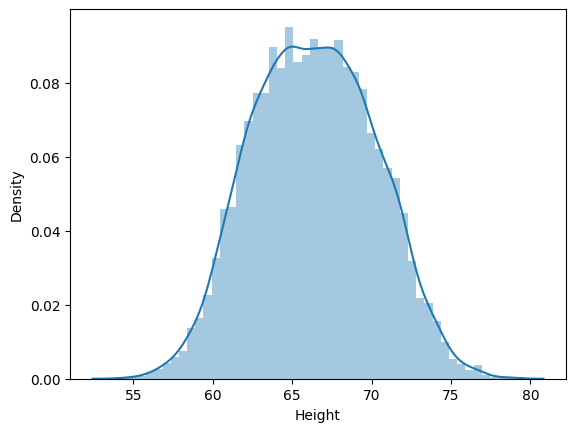

In [7]:
sns.distplot(df["Height"])

/tmp/ipykernel_8480/196129849.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Weight"])


<Axes: xlabel='Weight', ylabel='Density'>

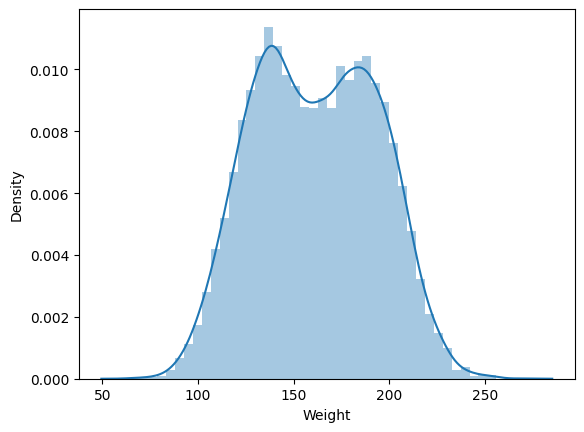

In [8]:
sns.distplot(df["Weight"])

<Axes: ylabel='Height'>

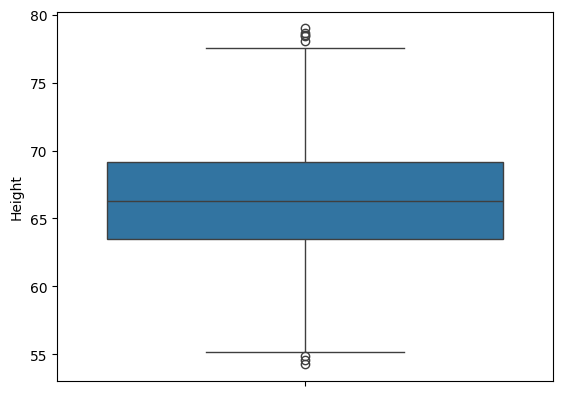

In [9]:
sns.boxplot(df["Height"])

In [10]:
upper_limit = df["Height"].quantile(0.99)

In [11]:
upper_limit

np.float64(74.7857900583366)

In [13]:
lower_limit = df["Height"].quantile(0.01)  # symtetric chalna ha upper se means aik 1 gap to 1 if 5 to 5

In [14]:
lower_limit

np.float64(58.13441158671655)

In [16]:
new_df = df[(df["Height"] <= 74.78) & (df["Height"] >= 58.13)] # so now just trimming 

In [18]:
new_df.sample(10)

,Gender,Height,Weight
1566,Male,66.574887,163.241255
980,Male,70.724758,214.261518
9797,Female,61.200995,115.901129
6171,Female,62.230714,108.192003
6542,Female,65.095308,156.062396
6642,Female,67.530860,157.715300
4665,Male,67.001350,183.826759
1968,Male,69.213632,205.699461
5880,Female,63.905647,169.079129
6998,Female,61.186259,109.582356


In [19]:
new_df.shape

(9799, 3)

<Axes: ylabel='Height'>

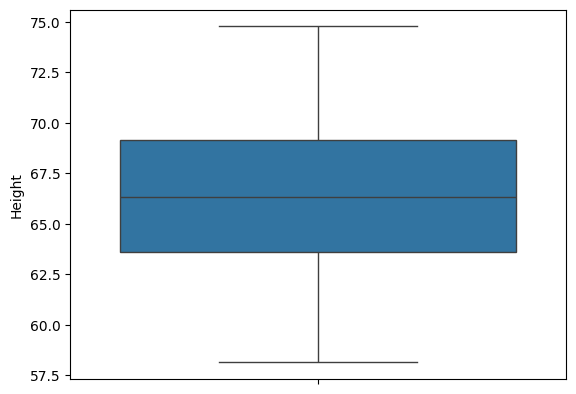

In [20]:
sns.boxplot(new_df["Height"])

/tmp/ipykernel_8480/3280797473.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df["Height"])


<Axes: xlabel='Height', ylabel='Density'>

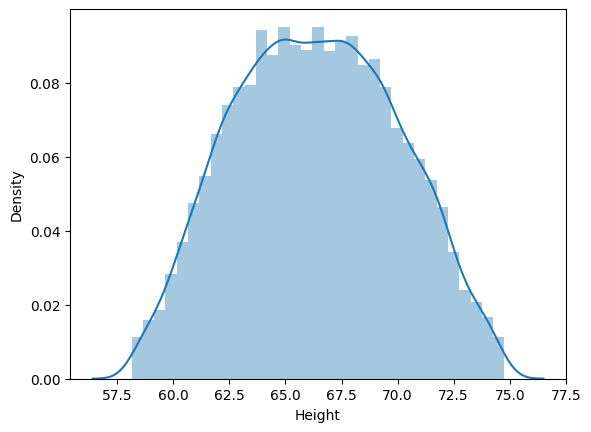

In [21]:
sns.distplot(new_df["Height"])

In [23]:
# capping => winserization in terms of percentile method

df["Height"] = np.where(
    df["Height"] >= upper_limit,
    upper_limit,
    np.where(
        df["Height"] <= lower_limit,
        lower_limit,
        df["Height"]
    )
)

In [24]:
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461
